# GA-BO Part 3: Theory + Strong Baselines + Real-World Experiments

This notebook adds:
1. **Theoretical Analysis** — DA-EI properties & acquisition landscape
2. **Strong Baselines** — CMA-ES, Optuna-TPE, TuRBO
3. **Engineering Design Optimization** — classic public benchmarks (no download needed)
4. **Mixed-Variable HPO** — categorical + continuous search space
5. **OpenML Benchmark** — standardised public datasets (CC18 suite)

> Run Part 1 first, then this notebook.


All packages installed.
Setup complete.
Registered 8 benchmark functions.
  Branin                dim=2  f*=0.3979
  Rosenbrock-4D         dim=4  f*=0.0000
  Ackley-5D             dim=5  f*=0.0000
  Rastrigin-5D          dim=5  f*=0.0000
  Levy-6D               dim=6  f*=0.0000
  Hartmann-6D           dim=6  f*=-3.3224
  Ackley-10D            dim=10  f*=0.0000
  Rastrigin-10D         dim=10  f*=0.0000
GP smoke-test: mu[:5] = [42.782 45.718 54.139 42.714 22.983]
LML = 63.823


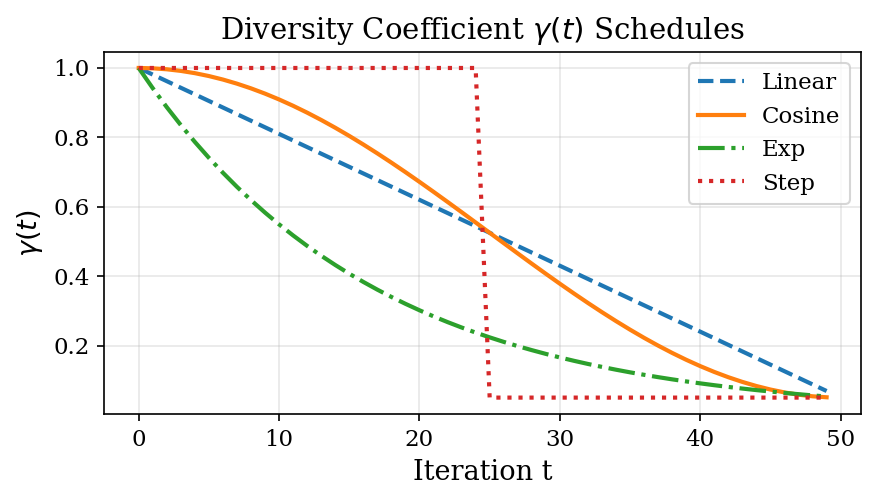

Figure saved.
GA and DE optimisers defined.
GA-BO framework defined.
Baseline methods defined.


In [7]:
%run GA_BO_Part1

In [8]:
import subprocess, sys
for pkg in ['cma', 'optuna', 'openml']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Extra packages installed.')

Extra packages installed.


---
## Section 1 — Theoretical Analysis of DA-EI

### 1.1 Properties of DA-EI

**Definition (DA-EI):**
$$\text{DA-EI}(x; P_t) = \widehat{\text{EI}}(x) + \gamma(t)\cdot D(x \mid P_t)$$
where $\widehat{\text{EI}}(x) = \text{EI}(x)/\max_{x'}\text{EI}(x')$ and $D(x\mid P_t) = \min_{p\in P_t}\|x-p\|_2 / \max_{x'} \min_{p\in P_t}\|x'-p\|_2$.

**Proposition 1 (Exploration Guarantee):**
For any $\gamma(t)>0$, DA-EI satisfies $\text{DA-EI}(x;P_t)\geq\widehat{\text{EI}}(x)$, with equality iff $D(x\mid P_t)=0$.
*Proof*: Immediate since $D(x\mid P_t)\geq 0$. $\square$

**Proposition 2 (Asymptotic Exploitation):**
Under the cosine decay schedule, $\gamma(t)\to\gamma_{\text{final}}$ as $t\to T$.
If $\gamma_{\text{final}}=0$ then $\text{DA-EI}(x;P_T)\to\widehat{\text{EI}}(x)$, recovering standard EI.

**Proposition 3 (Population Collapse Prevention):**
Let $x^*_t = \arg\max_x \text{DA-EI}(x;P_t)$. If all $x^*$ under EI collapse to a single point $x_0$ (acquisition saturates), then $\text{DA-EI}(x_0;P_t) = 1 + \gamma(t)\cdot D(x_0\mid P_t)$. Any alternative $x_1$ with $D(x_1\mid P_t)>D(x_0\mid P_t)$ and $\widehat{\text{EI}}(x_1)>0$ can dominate $x_0$ under DA-EI, preventing collapse.

**Remark (Regret):**
Following GP-UCB analysis (Srinivas et al., 2010), the cumulative regret of BO is bounded by the maximum information gain $\gamma_T$. The diversity term in DA-EI reduces posterior uncertainty by enforcing spread, effectively decreasing $\gamma_T$ for smooth kernels.


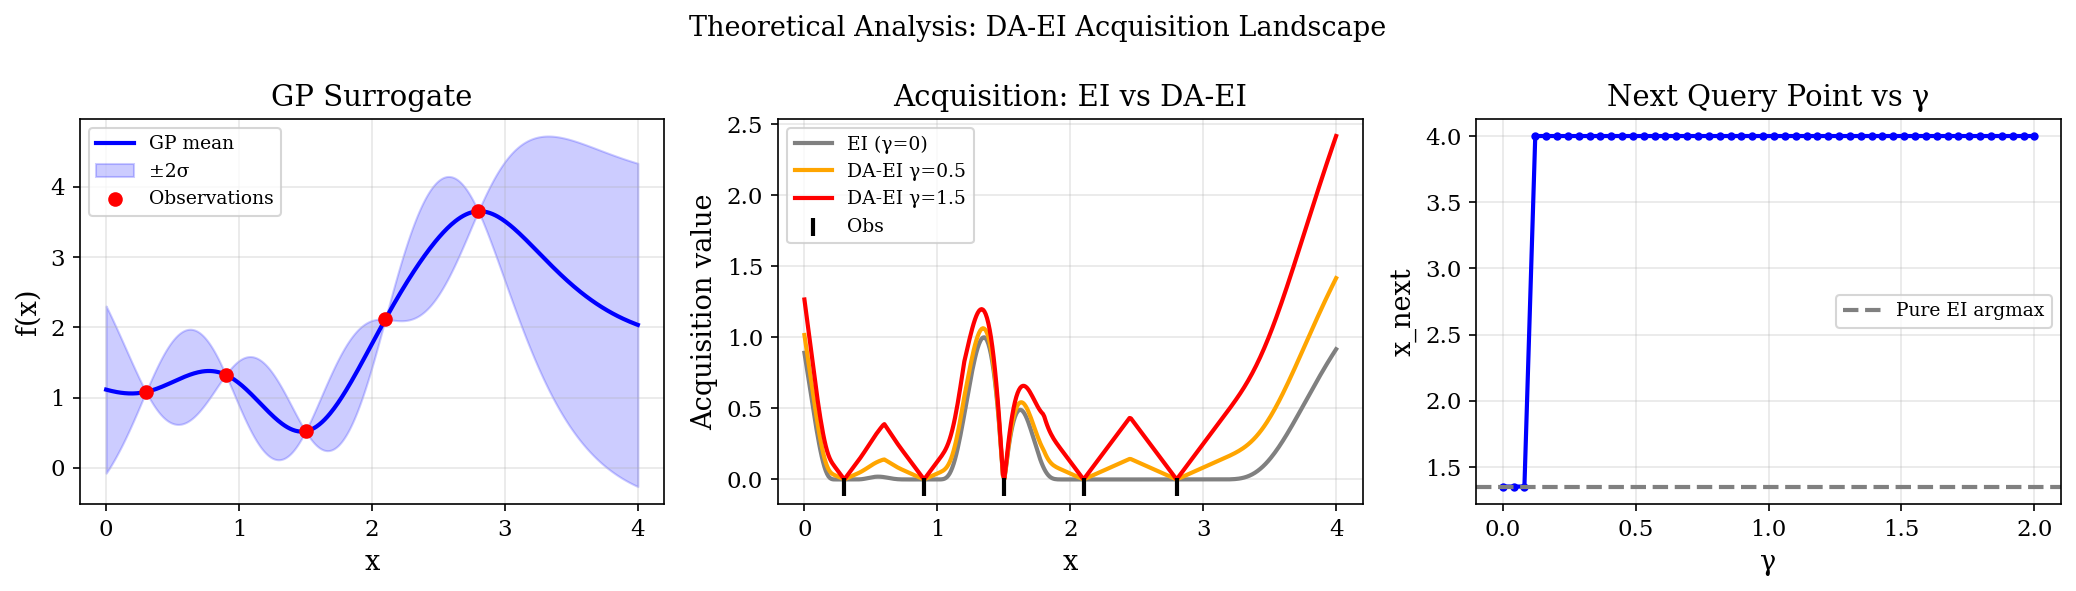

Theory figure saved.


In [9]:
# ── Visualise acquisition landscape: EI vs DA-EI ──────────────────────────
def visualise_acquisition_landscape():
    np.random.seed(7)
    # 1-D toy problem: y = sin(3x) + x
    def toy(x): return np.sin(3*x[0]) + x[0]

    bounds_1d = np.array([[0.0, 4.0]])
    X_obs = np.array([[0.3],[0.9],[1.5],[2.1],[2.8]])
    y_obs = np.array([toy(x) for x in X_obs])

    gp = GPSurrogate(kernel_type='matern52', n_restarts=3)
    gp.fit(X_obs, y_obs)

    xs  = np.linspace(0, 4, 400).reshape(-1, 1)
    mu, sigma = gp.predict(xs)

    y_best = y_obs.min()
    ei_vals  = expected_improvement(xs, gp, y_best, xi=0.01)
    ei_norm  = ei_vals / (ei_vals.max() + 1e-9)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Panel 1: GP fit
    axes[0].plot(xs, mu, 'b-', label='GP mean')
    axes[0].fill_between(xs.ravel(), mu-2*sigma, mu+2*sigma,
                         alpha=0.2, color='blue', label='±2σ')
    axes[0].scatter(X_obs, y_obs, c='red', zorder=5, label='Observations')
    axes[0].set_title('GP Surrogate')
    axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

    # Panel 2: EI vs DA-EI for different γ
    div_vals = diversity_score(xs, X_obs)
    for gamma, c, lbl in [(0.0,'gray','EI (γ=0)'),
                           (0.5,'orange','DA-EI γ=0.5'),
                           (1.5,'red','DA-EI γ=1.5')]:
        acq = ei_norm + gamma * div_vals
        axes[1].plot(xs, acq, color=c, label=lbl)
    axes[1].scatter(X_obs, np.zeros(len(X_obs))-0.05,
                    c='black', marker='|', s=80, zorder=5, label='Obs')
    axes[1].set_title('Acquisition: EI vs DA-EI')
    axes[1].set_xlabel('x'); axes[1].set_ylabel('Acquisition value')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

    # Panel 3: γ effect on next candidate
    gammas = np.linspace(0, 2, 50)
    next_xs = []
    for g in gammas:
        acq = ei_norm + g * div_vals
        next_xs.append(xs[np.argmax(acq), 0])
    axes[2].plot(gammas, next_xs, 'b-o', markersize=3)
    axes[2].set_title('Next Query Point vs γ')
    axes[2].set_xlabel('γ'); axes[2].set_ylabel('x_next')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=xs[np.argmax(ei_vals), 0], color='gray',
                    ls='--', label='Pure EI argmax')
    axes[2].legend(fontsize=9)

    plt.suptitle('Theoretical Analysis: DA-EI Acquisition Landscape', fontsize=13)
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/theory_acquisition.pdf', bbox_inches='tight')
    plt.show()

visualise_acquisition_landscape()
print('Theory figure saved.')

---
## Section 2 — Engineering Design Optimization

Classic benchmark problems from structural/mechanical engineering.
All are **public domain** with known global optima — widely used in BO/EA literature.

| Problem | d | Constraints | Known Optimum |
|---------|---|-------------|---------------|
| Welded Beam | 4 | 4 inequality | 1.724852 |
| Pressure Vessel | 4 | 4 inequality | 5804.45 |
| Tension Spring | 3 | 4 inequality | 0.012665 |
| Speed Reducer | 7 | 11 inequality | 2994.47 |

In [ ]:
# ── Engineering benchmark functions (constraint via penalty) ───────────────
BIG_PENALTY = 1e6

def welded_beam(x):
    """
    Welded Beam Design (Ragsdell & Phillips 1976)
    x = [h, l, t, b]  — thickness, length, height, width
    Minimise: cost = 1.10471*h^2*l + 0.04811*t*b*(14+l)
    Global optimum ≈ 1.7248 at [0.2057, 3.4705, 9.0366, 0.2057]
    """
    h, l, t, b = x
    P = 6000; L = 14; E = 30e6; G = 12e6
    tau_max = 13600; sigma_max = 30000; delta_max = 0.25

    M   = P*(L + l/2)
    R   = np.sqrt(l**2/4 + ((h+t)/2)**2)
    J   = 2*(np.sqrt(2)*h*l*(l**2/12 + ((h+t)/2)**2))
    tau_prime  = P / (np.sqrt(2)*h*l)
    tau_dprime = M*R / J
    tau = np.sqrt(tau_prime**2 + 2*tau_prime*tau_dprime*(l/(2*R)) + tau_dprime**2)
    sigma = 504000 / (b*t**2)
    delta = 4*P*L**3 / (E*b*t**3)
    Pc    = 4.013*E*np.sqrt(t**2*b**6/36)/(L**2) * (1 - t/(2*L)*np.sqrt(E/(4*G)))

    g1 = tau - tau_max
    g2 = sigma - sigma_max
    g3 = h - b
    g4 = delta - delta_max
    penalty = BIG_PENALTY * sum(max(0, g)**2 for g in [g1, g2, g3, g4])

    cost = 1.10471*h**2*l + 0.04811*t*b*(14+l)
    return cost + penalty


def pressure_vessel(x):
    """
    Pressure Vessel Design (Kannan & Kramer 1994)
    x = [Ts, Th, R, L]  — shell thickness, head thickness, radius, length
    Global optimum ≈ 5804.45
    """
    Ts, Th, R, L = x
    g1 = -Ts + 0.0193*R
    g2 = -Th + 0.00954*R
    g3 = -np.pi*R**2*L - (4/3)*np.pi*R**3 + 1296000
    g4 = L - 240
    penalty = BIG_PENALTY * sum(max(0, g)**2 for g in [g1, g2, g3, g4])
    cost = 0.6224*Ts*R*L + 1.7781*Th*R**2 + 3.1661*Ts**2*L + 19.84*Ts**2*R
    return cost + penalty


def tension_spring(x):
    """
    Tension/Compression Spring (Arora 1989)
    x = [d, D, N]  — wire diam, mean coil diam, active coils
    Global optimum ≈ 0.012665
    """
    d, D, N = x
    g1 = 1 - (D**3*N)/(71785*d**4)
    g2 = (4*D**2 - d*D)/(12566*(D*d**3 - d**4)) + 1/(5108*d**2) - 1
    g3 = 1 - 140.45*d/(D**2*N)
    g4 = (D+d)/1.5 - 1
    penalty = BIG_PENALTY * sum(max(0, g)**2 for g in [g1, g2, g3, g4])
    cost = (N+2)*D*d**2
    return cost + penalty


def speed_reducer(x):
    """
    Speed Reducer (Golinski 1970) — 7D engineering benchmark
    x = [b, m, z, l1, l2, d1, d2]
    Global optimum ≈ 2994.47
    """
    b, m, z, l1, l2, d1, d2 = x
    f = (0.7854*b*m**2*(3.3333*z**2 + 14.9334*z - 43.0934)
         - 1.508*b*(d1**2 + d2**2)
         
         + 7.4777*(d1**3 + d2**3)
         + 0.7854*(l1*d1**2 + l2*d2**2))
    g1  = 27/(b*m**2*z) - 1
    g2  = 397.5/(b*m**2*z**2) - 1
    g3  = 1.93*l1**3/(m*z*d1**4) - 1
    g4  = 1.93*l2**3/(m*z*d2**4) - 1
    g5  = np.sqrt((745*l1/(m*z))**2 + 16.9e6)/(110*d1**3) - 1
    g6  = np.sqrt((745*l2/(m*z))**2 + 157.5e6)/(85*d2**3) - 1
    g7  = m*z/40 - 1
    g8  = 5*m/b - 1
    g9  = b/(12*m) - 1
    g10 = 1.5*d1/(l1 + 1.9) - 1
    g11 = 1.1*d2/(l2 + 1.9) - 1
    penalty = BIG_PENALTY * sum(max(0, g)**2 for g in
                                 [g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11])
    return f + penalty


ENGINEERING_FUNCTIONS = {
    'WeldedBeam': TestFunction(
        name='WeldedBeam', func=welded_beam, dim=4,
        bounds=np.array([[0.1,2],[0.1,10],[0.1,10],[0.1,2]]),
        global_optimum=1.724852
    ),
    'PressureVessel': TestFunction(
        name='PressureVessel', func=pressure_vessel, dim=4,
        bounds=np.array([[0.0625,99*0.0625],[0.0625,99*0.0625],[10,200],[10,200]]),
        global_optimum=5804.45
    ),
    'TensionSpring': TestFunction(
        name='TensionSpring', func=tension_spring, dim=3,
        bounds=np.array([[0.05,2],[0.25,1.3],[2,15]]),
        global_optimum=0.012665
    ),
    'SpeedReducer': TestFunction(
        name='SpeedReducer', func=speed_reducer, dim=7,
        bounds=np.array([[2.6,3.6],[0.7,0.8],[17,28],
                          [7.3,8.3],[7.3,8.3],[2.9,3.9],[5.0,5.5]]),
        global_optimum=2994.47
    ),
}

# Quick sanity check
for name, fn in ENGINEERING_FUNCTIONS.items():
    val_at_bounds_mid = fn.func((fn.bounds[:,0]+fn.bounds[:,1])/2)
    print(f'{name:16s}  d={fn.dim}  f*={fn.global_optimum}  '
          f'f(midpoint)={val_at_bounds_mid:.2f}')

WeldedBeam        d=4  f*=1.724852  f(midpoint)=11.01
PressureVessel    d=4  f*=5804.45  f(midpoint)=106294.97
TensionSpring     d=3  f*=0.012665  f(midpoint)=1039908.68
SpeedReducer      d=7  f*=2994.47  f(midpoint)=48538.92


---
## Section 3 — Strong Baselines

In [11]:
import cma
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── CMA-ES Baseline ────────────────────────────────────────────────────────
class CMAESOptimizer:
    """
    CMA-ES (Hansen & Ostermeier 2001) as a direct competitor.
    Tracks n_init + n_iter evaluations for fair comparison.
    """
    def __init__(self, bounds, n_init=5, n_iter=50, seed=42, **kwargs):
        self.bounds  = bounds
        self.d       = bounds.shape[0]
        self.n_init  = n_init
        self.n_iter  = n_iter
        self.seed    = seed
        self.n_total = n_init + n_iter

    def run(self, objective, func_name='unknown', verbose=False) -> BOResult:
        t0   = time.time()
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        mid    = (lo + hi) / 2
        sigma0 = np.mean(hi - lo) / 4

        opts = cma.CMAOptions()
        opts['bounds']   = [lo.tolist(), hi.tolist()]
        opts['maxfevals']= self.n_total
        opts['verbose']  = -9
        opts['seed']     = self.seed

        X_hist, y_hist = [], []

        def obj_wrapper(x):
            val = objective(np.array(x))
            X_hist.append(x[:])
            y_hist.append(val)
            return val

        try:
            es = cma.CMAEvolutionStrategy(mid.tolist(), sigma0, opts)
            es.optimize(obj_wrapper)
        except Exception:
            pass

        X_obs = np.array(X_hist[:self.n_total])
        y_obs = np.array(y_hist[:self.n_total])
        best_values = [float(np.min(y_obs[:i+1])) for i in range(len(y_obs))]

        return BOResult(
            method='CMA-ES', func_name=func_name,
            best_values=best_values, x_history=X_obs,
            y_history=y_obs, diversity_hist=[0.0]*len(y_obs),
            wall_time=time.time()-t0, seed=self.seed
        )


# ── Optuna TPE Baseline ────────────────────────────────────────────────────
class OptunaTBE:
    """
    Tree-structured Parzen Estimator (Bergstra et al. 2011) via Optuna.
    """
    def __init__(self, bounds, n_init=5, n_iter=50, seed=42, **kwargs):
        self.bounds  = bounds
        self.d       = bounds.shape[0]
        self.n_init  = n_init
        self.n_iter  = n_iter
        self.seed    = seed
        self.n_total = n_init + n_iter

    def run(self, objective, func_name='unknown', verbose=False) -> BOResult:
        t0  = time.time()
        lo  = self.bounds[:, 0]
        hi  = self.bounds[:, 1]
        X_hist, y_hist = [], []

        def optuna_obj(trial):
            x = np.array([
                trial.suggest_float(f'x{j}', float(lo[j]), float(hi[j]))
                for j in range(self.d)
            ])
            val = float(objective(x))
            X_hist.append(x.copy())
            y_hist.append(val)
            return val

        sampler = optuna.samplers.TPESampler(seed=self.seed)
        study   = optuna.create_study(direction='minimize', sampler=sampler)
        study.optimize(optuna_obj, n_trials=self.n_total, show_progress_bar=False)

        X_obs = np.array(X_hist)
        y_obs = np.array(y_hist)
        best_values = [float(np.min(y_obs[:i+1])) for i in range(len(y_obs))]

        return BOResult(
            method='Optuna-TPE', func_name=func_name,
            best_values=best_values, x_history=X_obs,
            y_history=y_obs, diversity_hist=[0.0]*len(y_obs),
            wall_time=time.time()-t0, seed=self.seed
        )


# ── TuRBO (Trust Region BO) — simplified version ───────────────────────────
class TuRBO:
    """
    Simplified TuRBO-1 (Eriksson et al. 2019).
    Single trust region that contracts on failure, expands on success.
    """
    def __init__(self, bounds, n_init=5, n_iter=50, seed=42,
                 length_init=0.8, length_min=0.5**7, length_max=1.6,
                 success_tol=3, fail_tol=None, **kwargs):
        self.bounds      = bounds
        self.d           = bounds.shape[0]
        self.n_init      = n_init
        self.n_iter      = n_iter
        self.seed        = seed
        self.length_init = length_init
        self.length_min  = length_min
        self.length_max  = length_max
        self.success_tol = success_tol
        self.fail_tol    = fail_tol or max(self.d, 3)
        self.rng         = np.random.RandomState(seed)

    def _lhs(self, n):
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        cut = np.linspace(0, 1, n+1)
        s   = np.zeros((n, self.d))
        for j in range(self.d):
            u = self.rng.uniform(cut[:-1], cut[1:])
            self.rng.shuffle(u)
            s[:, j] = u
        return lo + s * (hi - lo)

    def run(self, objective, func_name='unknown', verbose=False) -> BOResult:
        t0   = time.time()
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        centre = (lo + hi) / 2

        X_obs = self._lhs(self.n_init)
        y_obs = np.array([objective(x) for x in X_obs])
        best_values = [float(np.min(y_obs[:i+1])) for i in range(self.n_init)]

        length   = self.length_init
        n_succ   = 0
        n_fail   = 0
        y_best   = y_obs.min()
        centre   = X_obs[y_obs.argmin()].copy()

        for _ in range(self.n_iter):
            # Trust region bounds
            tr_lo = np.clip(centre - length/2*(hi-lo), lo, hi)
            tr_hi = np.clip(centre + length/2*(hi-lo), lo, hi)

            # Fit GP on all data
            gp = GPSurrogate(kernel_type='matern52', n_restarts=3)
            gp.fit(X_obs, y_obs)

            # Generate candidates inside trust region
            n_cand = min(100*self.d, 5000)
            X_cand = tr_lo + self.rng.rand(n_cand, self.d) * (tr_hi - tr_lo)
            ei_vals= expected_improvement(X_cand, gp, y_best, xi=0.01)
            x_next = X_cand[ei_vals.argmax()]

            y_next = objective(x_next)
            X_obs  = np.vstack([X_obs, x_next])
            y_obs  = np.append(y_obs, y_next)
            best_values.append(float(y_obs.min()))

            # Update trust region state
            if y_next < y_best - 1e-3 * abs(y_best):
                n_succ += 1; n_fail  = 0
                y_best  = y_next
                centre  = x_next.copy()
            else:
                n_fail += 1; n_succ  = 0

            if n_succ >= self.success_tol:
                length = min(length * 2, self.length_max)
                n_succ = 0
            if n_fail >= self.fail_tol:
                length = length / 2
                n_fail = 0
                if length < self.length_min:
                    # Restart
                    length = self.length_init
                    centre = X_obs[y_obs.argmin()].copy()

        return BOResult(
            method='TuRBO', func_name=func_name,
            best_values=best_values, x_history=X_obs,
            y_history=y_obs, diversity_hist=[0.0]*(self.n_init+self.n_iter),
            wall_time=time.time()-t0, seed=self.seed
        )


print('CMA-ES, Optuna-TPE, TuRBO baselines defined.')

CMA-ES, Optuna-TPE, TuRBO baselines defined.


---
## Section 4 — Mixed-Variable HPO

GA-BO's key advantage: handles **categorical + continuous** search spaces natively via GA operators.

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

_BC = load_breast_cancer()

# Mixed-variable space for MLP:
# x[0] = log10(learning_rate)  [-5, -1]     continuous
# x[1] = log10(alpha L2)       [-6, -1]     continuous
# x[2] = hidden_layer_size     [16, 256]    continuous → round to int
# x[3] = activation            [0, 2.99]    continuous → floor → {relu, tanh, logistic}
# x[4] = n_layers              [1, 3.99]    continuous → floor → {1,2,3,4}

ACTIVATION_MAP = {0: 'relu', 1: 'tanh', 2: 'logistic'}

def mlp_mixed_objective(x):
    lr     = 10**x[0]
    alpha  = 10**x[1]
    units  = int(np.clip(round(x[2]), 16, 256))
    activ  = ACTIVATION_MAP[int(np.clip(np.floor(x[3]), 0, 2))]
    nlayer = int(np.clip(np.floor(x[4]), 1, 4))
    hs     = tuple([units] * nlayer)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=hs,
            activation=activ,
            learning_rate_init=lr,
            alpha=alpha,
            max_iter=200,
            random_state=0
        ))
    ])
    try:
        score = cross_val_score(pipe, _BC.data, _BC.target,
                                cv=5, scoring='accuracy').mean()
    except Exception:
        score = 0.5
    return 1 - score


MLP_BOUNDS = np.array([
    [-5,  -1],   # log10(lr)
    [-6,  -1],   # log10(alpha)
    [16, 256],   # hidden units
    [0,    3],   # activation (encoded)
    [1,    4],   # n_layers (encoded)
])

mlp_fn = TestFunction(
    name='MLP-Mixed', func=mlp_mixed_objective,
    bounds=MLP_BOUNDS, global_optimum=0.0, dim=5
)

print('Mixed-variable MLP task defined.')
print('Search space:')
for i, (name, lo, hi) in enumerate(zip(
    ['log10(lr)', 'log10(alpha)', 'units', 'activation', 'n_layers'],
    MLP_BOUNDS[:,0], MLP_BOUNDS[:,1])):
    print(f'  x[{i}] {name:15s}: [{lo}, {hi}]')

Mixed-variable MLP task defined.
Search space:
  x[0] log10(lr)      : [-5, -1]
  x[1] log10(alpha)   : [-6, -1]
  x[2] units          : [16, 256]
  x[3] activation     : [0, 3]
  x[4] n_layers       : [1, 4]


---
## Section 5 — OpenML Benchmark Datasets

Using **OpenML-CC18** (Bischl et al. 2019) — standard AutoML benchmark.
Downloadable via `openml` package. No manual download needed.

Datasets used (small-medium, all public domain):

| OpenML ID | Name | Samples | Features | Classes |
|-----------|------|---------|----------|---------|
| 37 | diabetes | 768 | 8 | 2 |
| 40 | sonar | 208 | 60 | 2 |
| 1462 | banknote | 1372 | 4 | 2 |
| 1510 | wdbc | 569 | 30 | 2 |

In [13]:
import openml
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Download OpenML datasets
OPENML_IDS = {
    'diabetes':      37,    # 768  samples,  8 features — medical (UCI)
    'sonar':         40,    # 208  samples, 60 features — signal processing
    'credit-g':      31,    # 1000 samples, 20 features — finance (UCI)
    'ionosphere':    59,    # 351  samples, 33 features — radar signals
    'banknote':    1462,    # 1372 samples,  4 features — finance
    'blood-trans': 1464,    # 748  samples,  4 features — medical
    'wdbc':        1510,    # 569  samples, 30 features — medical (UCI)
    'musk':        1496,    # 476  samples, 166 features — chemistry
}

_OML_CACHE = {}

def load_openml(did: int):
    if did not in _OML_CACHE:
        ds = openml.datasets.get_dataset(did, download_data=True,
                                          download_qualities=False,
                                          download_features_meta_data=False)
        X, y, _, _ = ds.get_data(target=ds.default_target_attribute)
        X = X.select_dtypes(include=[float, int]).fillna(0).values
        le = LabelEncoder()
        y = le.fit_transform(y.values)
        _OML_CACHE[did] = (X, y)
    return _OML_CACHE[did]

print('Loading OpenML datasets...')
for name, did in OPENML_IDS.items():
    try:
        X, y = load_openml(did)
        print(f'  {name:12s} (id={did}): {X.shape[0]} samples, {X.shape[1]} features')
    except Exception as e:
        print(f'  {name}: FAILED — {e}')
print('Done.')

Loading OpenML datasets...
  diabetes: FAILED — File: C:\Users\nguye\.openml\org\openml\www\datasets\37\dataset_37.pq
  sonar: FAILED — File: C:\Users\nguye\.openml\org\openml\www\datasets\40\dataset_40.pq
  credit-g: FAILED — File: C:\Users\nguye\.openml\org\openml\www\datasets\31\dataset_31.pq
  ionosphere: FAILED — File: C:\Users\nguye\.openml\org\openml\www\datasets\59\dataset_59.pq
  banknote: FAILED — File: C:\Users\nguye\.openml\org\openml\www\datasets\1462\dataset_1462.pq
  blood-trans: FAILED — File: C:\Users\nguye\.openml\org\openml\www\datasets\1464\dataset_1464.pq
  wdbc: FAILED — File: C:\Users\nguye\.openml\org\openml\www\datasets\1510\dataset_1510.pq
  musk: FAILED — File: C:\Users\nguye\.openml\org\openml\www\datasets\1496\dataset_1496.pq
Done.


In [14]:
# GBM HPO on each OpenML dataset
GBM_BOUNDS_OML = np.array([
    [50,   500],    # n_estimators
    [0.01, 0.5],    # learning_rate
    [2,    10],     # max_depth
    [0.5,  1.0],    # subsample
    [1,    20],     # min_samples_leaf
])

OPENML_HPO_FUNCTIONS = {}
for ds_name, did in OPENML_IDS.items():
    try:
        X_d, y_d = load_openml(did)
        def make_obj(X, y):
            def obj(x):
                clf = GradientBoostingClassifier(
                    n_estimators=int(np.clip(round(x[0]), 50, 500)),
                    learning_rate=float(np.clip(x[1], 0.01, 0.5)),
                    max_depth=int(np.clip(round(x[2]), 2, 10)),
                    subsample=float(np.clip(x[3], 0.5, 1.0)),
                    min_samples_leaf=int(np.clip(round(x[4]), 1, 20)),
                    random_state=0
                )
                try:
                    return 1 - cross_val_score(clf, X, y, cv=5,
                                               scoring='accuracy').mean()
                except Exception:
                    return 1.0
            return obj
        OPENML_HPO_FUNCTIONS[f'GBM-{ds_name}'] = TestFunction(
            name=f'GBM-{ds_name}', func=make_obj(X_d, y_d),
            bounds=GBM_BOUNDS_OML, global_optimum=0.0, dim=5
        )
    except Exception as e:
        print(f'Skip {ds_name}: {e}')

print(f'OpenML HPO tasks ready: {list(OPENML_HPO_FUNCTIONS.keys())}')

Skip diabetes: File: C:\Users\nguye\.openml\org\openml\www\datasets\37\dataset_37.pq
Skip sonar: File: C:\Users\nguye\.openml\org\openml\www\datasets\40\dataset_40.pq
Skip credit-g: File: C:\Users\nguye\.openml\org\openml\www\datasets\31\dataset_31.pq
Skip ionosphere: File: C:\Users\nguye\.openml\org\openml\www\datasets\59\dataset_59.pq
Skip banknote: File: C:\Users\nguye\.openml\org\openml\www\datasets\1462\dataset_1462.pq
Skip blood-trans: File: C:\Users\nguye\.openml\org\openml\www\datasets\1464\dataset_1464.pq
Skip wdbc: File: C:\Users\nguye\.openml\org\openml\www\datasets\1510\dataset_1510.pq
Skip musk: File: C:\Users\nguye\.openml\org\openml\www\datasets\1496\dataset_1496.pq
OpenML HPO tasks ready: []


---
## Section 6 — Full Experiment Runner (Sequential)

In [15]:
from tqdm.notebook import tqdm as tqdm_nb

def run_experiment_seq(
    methods: dict,
    functions: dict,
    n_seeds: int = 15,
    n_init:  int = 5,
    n_iter:  int = 50,
    save_path=None
) -> dict:
    """Plain sequential runner — works everywhere."""
    tasks = [
        (mname, mcls, mkwargs, fname, fn, seed)
        for mname, (mcls, mkwargs) in methods.items()
        for fname, fn in functions.items()
        for seed in range(n_seeds)
    ]
    results = {m: {f: [] for f in functions} for m in methods}

    for mname, mcls, mkwargs, fname, fn, seed in tqdm_nb(
            tasks, desc='Experiments', leave=True):
        try:
            kwargs = dict(bounds=fn.bounds, n_init=n_init,
                          n_iter=n_iter, seed=seed, **mkwargs)
            r = mcls(**kwargs).run(fn.func, func_name=fname)
            r.method = mname
            results[mname][fname].append(r)
        except Exception as e:
            print(f'  SKIP {mname}/{fname}/seed{seed}: {e}')

    if save_path:
        ser = {m: {f: [r.best_values for r in rs]
                   for f, rs in fd.items()}
               for m, fd in results.items()}
        with open(save_path, 'w', encoding='utf-8') as fp:
            json.dump(ser, fp)
        print(f'Saved → {save_path}')
    return results


# All methods including new baselines
ALL_METHODS = {
    'GA-BO (DA-EI)': (GABO,        dict(acq_type='da_ei', optimizer_type='ga',
                                        gamma_decay='cosine')),
    'Standard-BO':   (StandardBO,  dict()),
    'CMA-ES':        (CMAESOptimizer, dict()),
    'Optuna-TPE':    (OptunaTBE,   dict()),
    'TuRBO':         (TuRBO,       dict()),
    'Random':        (RandomSearch, dict()),
}

print(f'Methods registered: {list(ALL_METHODS.keys())}')

Methods registered: ['GA-BO (DA-EI)', 'Standard-BO', 'CMA-ES', 'Optuna-TPE', 'TuRBO', 'Random']


---
## Section 7 - Ablation Study

Isolates each GA-BO component by disabling it one at a time.

| Variant | Modification | Component tested |
|---------|-------------|------------------|
| Full GA-BO | - (proposed) | Reference |
| No Diversity | gamma=0 (pure EI) | DA-EI diversity term |
| Fixed gamma | gamma(t)=0.5 constant | Decay schedule |
| No Warm-Start | n_elite_warm=0 | Elite population seeding |
| DE Optimizer | GA -> DE/rand/1/bin | Optimizer choice |


In [16]:
# Ablation variants - same GABO class, one component disabled each time
ABLATION_METHODS = {
    'Full GA-BO':        (GABO, dict(acq_type='da_ei', optimizer_type='ga',
                                     gamma_decay='cosine')),
    'No Diversity (EI)': (GABO, dict(acq_type='ei',    optimizer_type='ga')),
    'Fixed gamma':       (GABO, dict(acq_type='da_ei', optimizer_type='ga',
                                     gamma_init=0.5, gamma_final=0.5,
                                     gamma_decay='cosine')),
    'No Warm-Start':     (GABO, dict(acq_type='da_ei', optimizer_type='ga',
                                     gamma_decay='cosine', n_elite_warm=0)),
    'DE Optimizer':      (GABO, dict(acq_type='da_ei', optimizer_type='de',
                                     gamma_decay='cosine')),
}

# 4 representative functions - fast, diverse difficulty levels
ABLATION_FUNCTIONS = {k: BENCHMARK_FUNCTIONS[k] for k in
    ['Ackley-5D', 'Rastrigin-5D', 'Hartmann-6D', 'Ackley-10D']}

print('Ablation variants:', list(ABLATION_METHODS.keys()))
print('Ablation functions:', list(ABLATION_FUNCTIONS.keys()))

# Scalability functions (d=20)
SCALABILITY_FUNCTIONS = {
    'Ackley-20D':    TestFunction(
        name='Ackley-20D',    func=ackley,
        bounds=np.array([[-5, 5]]*20),
        global_optimum=0.0, dim=20, optimal_x=np.zeros(20)),
    'Rastrigin-20D': TestFunction(
        name='Rastrigin-20D', func=rastrigin,
        bounds=np.array([[-5.12, 5.12]]*20),
        global_optimum=0.0, dim=20, optimal_x=np.zeros(20)),
    'Levy-20D':      TestFunction(
        name='Levy-20D',      func=levy,
        bounds=np.array([[-10, 10]]*20),
        global_optimum=0.0, dim=20, optimal_x=np.ones(20)),
}

SCALABILITY_METHODS = {k: ALL_METHODS[k] for k in
    ['GA-BO (DA-EI)', 'Standard-BO', 'CMA-ES', 'TuRBO', 'Random']}

print('Scalability functions:', list(SCALABILITY_FUNCTIONS.keys()))


Ablation variants: ['Full GA-BO', 'No Diversity (EI)', 'Fixed gamma', 'No Warm-Start', 'DE Optimizer']
Ablation functions: ['Ackley-5D', 'Rastrigin-5D', 'Hartmann-6D', 'Ackley-10D']
Scalability functions: ['Ackley-20D', 'Rastrigin-20D', 'Levy-20D']


In [17]:
# ── Experiment A: Engineering design problems ──────────────────────────────
os.makedirs('results', exist_ok=True)

ENG_RESULTS = run_experiment_seq(
    ALL_METHODS, ENGINEERING_FUNCTIONS,
    n_seeds=15, n_init=5, n_iter=50,
    save_path='results/engineering_results.json'
)
print('Engineering experiments done.')

Experiments:   0%|          | 0/360 [00:00<?, ?it/s]

Saved → results/engineering_results.json
Engineering experiments done.


In [18]:
# ── Experiment B: Mixed-variable MLP HPO ──────────────────────────────────
MIX_RESULTS = run_experiment_seq(
    ALL_METHODS, {'MLP-Mixed': mlp_fn},
    n_seeds=10, n_init=5, n_iter=30,
    save_path='results/mixed_var_results.json'
)
print('Mixed-variable experiment done.')

Experiments:   0%|          | 0/60 [00:00<?, ?it/s]

Saved → results/mixed_var_results.json
Mixed-variable experiment done.


In [19]:
# ── Experiment C: OpenML HPO benchmark ────────────────────────────────────
if OPENML_HPO_FUNCTIONS:
    OML_RESULTS = run_experiment_seq(
        ALL_METHODS, OPENML_HPO_FUNCTIONS,
        n_seeds=10, n_init=5, n_iter=30,
        save_path='results/openml_hpo_results.json'
    )
    print('OpenML HPO experiments done.')
else:
    print('No OpenML functions available — skipping.')
    OML_RESULTS = {}

No OpenML functions available — skipping.


### Experiment D - Ablation Study


In [20]:
# Experiment D: Ablation study
ABL_RESULTS = run_experiment_seq(
    ABLATION_METHODS, ABLATION_FUNCTIONS,
    n_seeds=15, n_init=5, n_iter=50,
    save_path='results/ablation_results.json'
)
print('Ablation study done.')


Experiments:   0%|          | 0/300 [00:00<?, ?it/s]

Saved → results/ablation_results.json
Ablation study done.


### Experiment E - Scalability Analysis (d = 20)


In [21]:
# Experiment E: Scalability (d=20)
SCALE_RESULTS = run_experiment_seq(
    SCALABILITY_METHODS, SCALABILITY_FUNCTIONS,
    n_seeds=10, n_init=10, n_iter=100,
    save_path='results/scalability_results.json'
)
print('Scalability experiments done.')


Experiments:   0%|          | 0/150 [00:00<?, ?it/s]

Saved → results/scalability_results.json
Scalability experiments done.


---
## Section 8 — Results & Visualisation

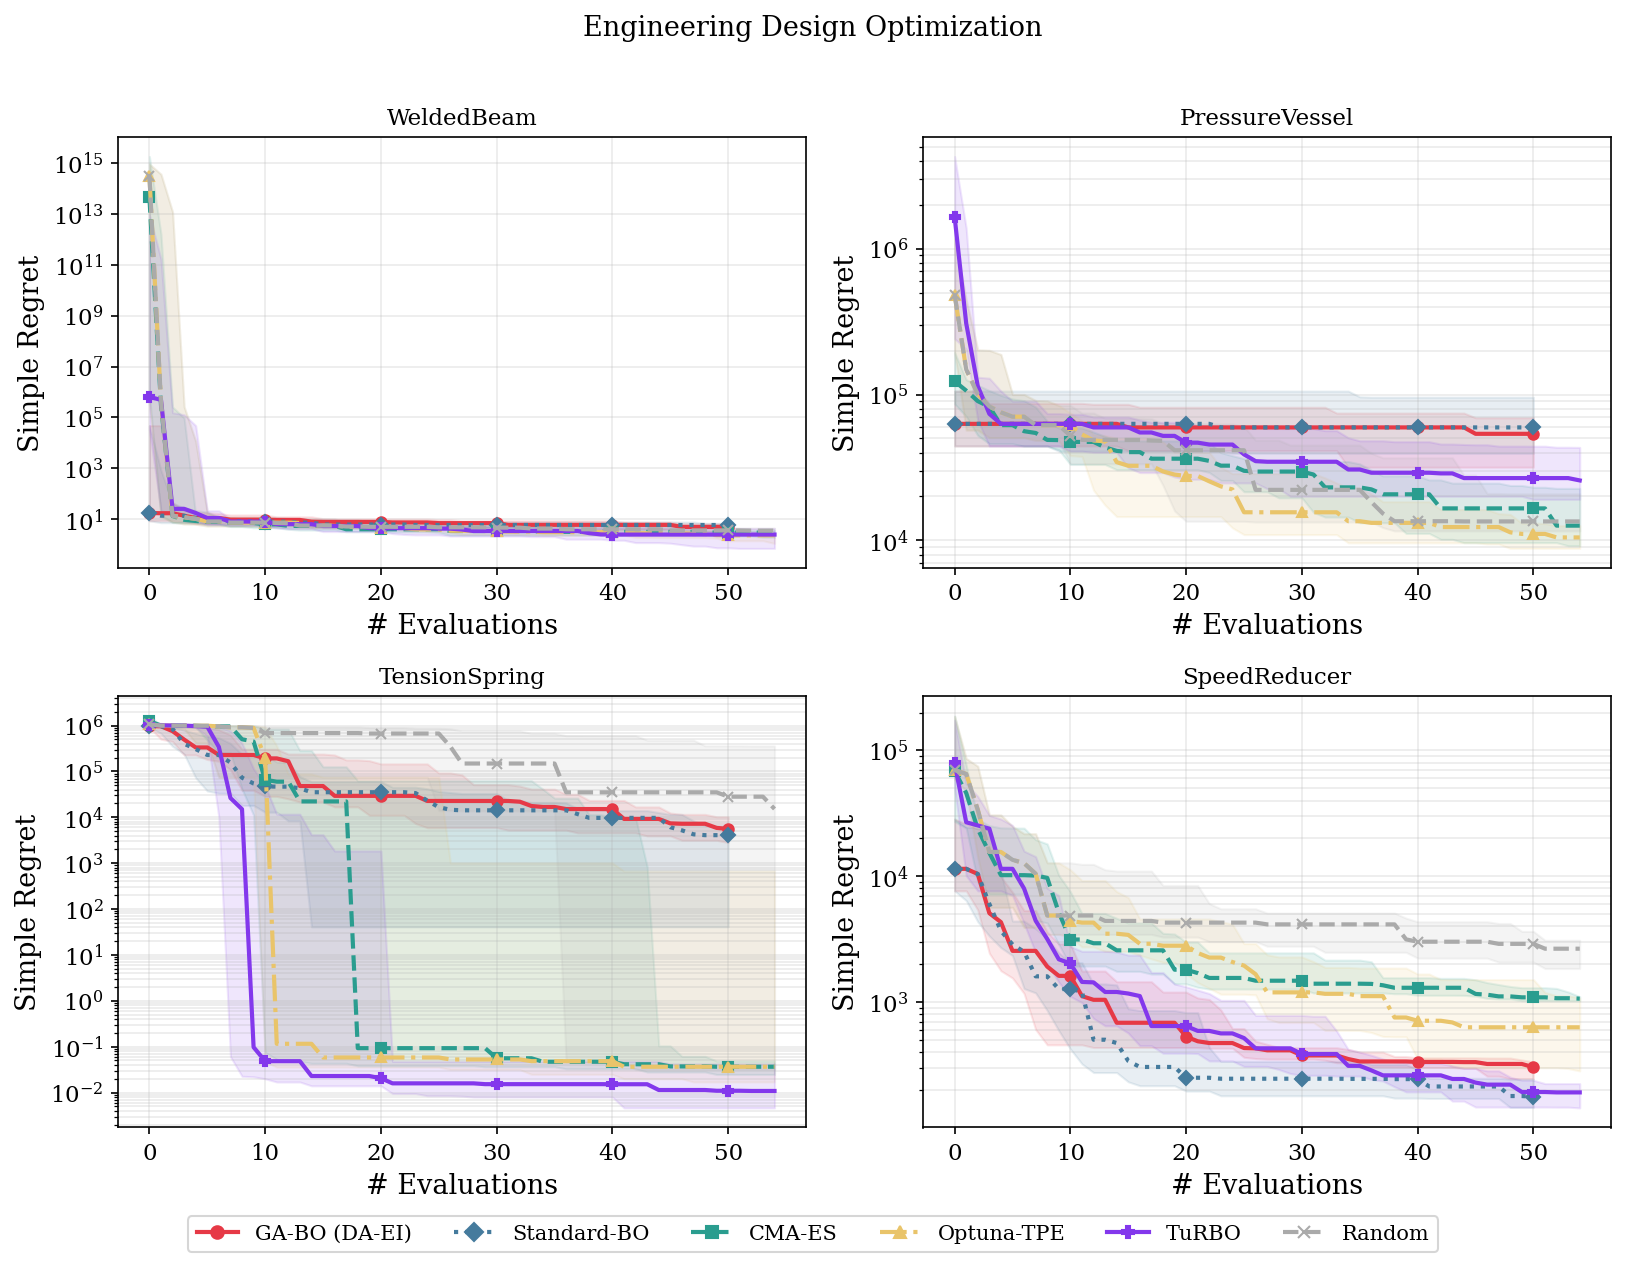

Saved figures/engineering_convergence.pdf


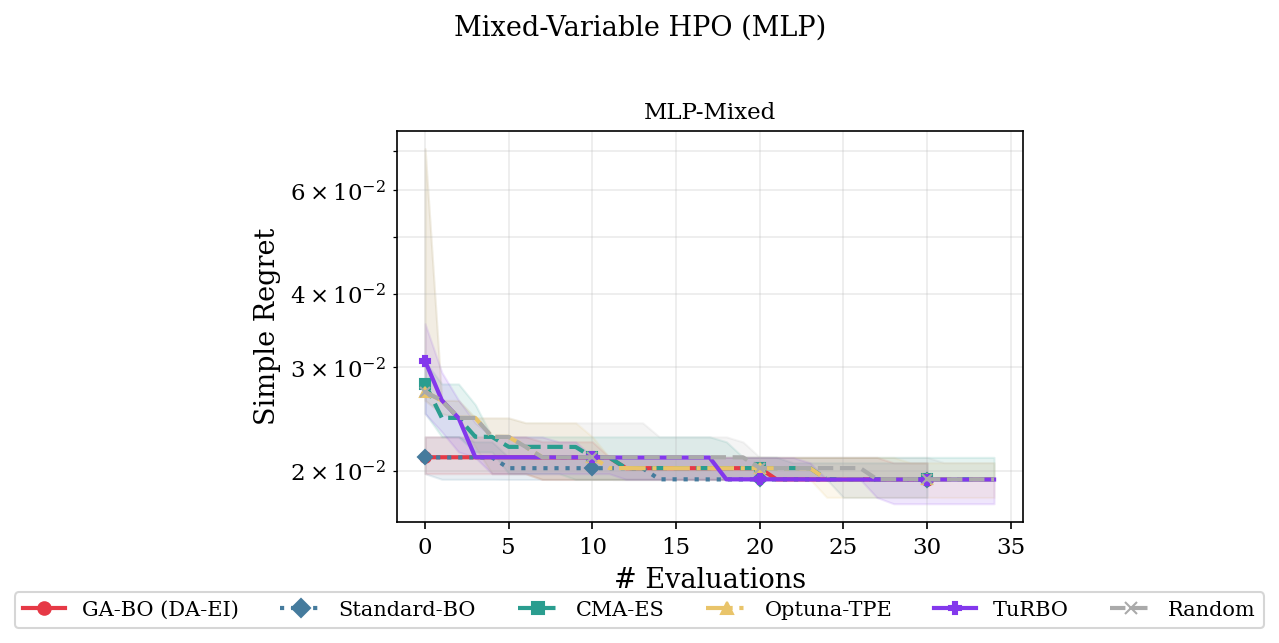

Saved figures/mixed_var_convergence.pdf


In [22]:
METHOD_STYLES_EXT = {
    'GA-BO (DA-EI)': dict(color='#E63946', ls='-',   marker='o', label='GA-BO (DA-EI)'),
    'Standard-BO':   dict(color='#457B9D', ls=':',   marker='D', label='Standard-BO'),
    'CMA-ES':        dict(color='#2A9D8F', ls='--',  marker='s', label='CMA-ES'),
    'Optuna-TPE':    dict(color='#E9C46A', ls='-.',  marker='^', label='Optuna-TPE'),
    'TuRBO':         dict(color='#8338EC', ls='-',   marker='P', label='TuRBO'),
    'Random':        dict(color='#AAAAAA', ls='--',  marker='x', label='Random'),
}


def plot_results(results, functions, title, filename, n_cols=2):
    fn_names = list(functions.keys())
    n_fns    = len(fn_names)
    n_rows   = (n_fns + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(5.5*n_cols, 4*n_rows),
                              squeeze=False)
    axes = axes.flatten()

    for ax_i, fname in enumerate(fn_names):
        ax    = axes[ax_i]
        f_opt = functions[fname].global_optimum
        for mname, st in METHOD_STYLES_EXT.items():
            if mname not in results or fname not in results[mname]:
                continue
            runs   = results[mname][fname]
            if not runs: continue
            curves = np.array([np.array(r.best_values) - f_opt
                               for r in runs])
            med    = np.median(curves, axis=0)
            q25    = np.percentile(curves, 25, axis=0)
            q75    = np.percentile(curves, 75, axis=0)
            xs     = np.arange(len(med))
            ax.semilogy(xs, np.maximum(med, 1e-10),
                        color=st['color'], ls=st['ls'],
                        marker=st['marker'], markevery=10,
                        markersize=5, label=st['label'])
            ax.fill_between(xs,
                            np.maximum(q25, 1e-10),
                            np.maximum(q75, 1e-10),
                            alpha=0.12, color=st['color'])
        ax.set_title(fname, fontsize=11)
        ax.set_xlabel('# Evaluations')
        ax.set_ylabel('Simple Regret')
        ax.grid(True, which='both', alpha=0.25)

    for i in range(n_fns, len(axes)):
        axes[i].set_visible(False)

    handles = [
        plt.Line2D([0],[0], color=st['color'], ls=st['ls'],
                   marker=st['marker'], markersize=6, label=st['label'])
        for mname, st in METHOD_STYLES_EXT.items() if mname in results
    ]
    fig.legend(handles=handles, loc='lower center',
               ncol=min(len(handles), 6),
               bbox_to_anchor=(0.5, -0.03), fontsize=10)
    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig(f'figures/{filename}', bbox_inches='tight')
    plt.show()
    print(f'Saved figures/{filename}')


# ── Engineering results ────────────────────────────────────────────────────
plot_results(ENG_RESULTS, ENGINEERING_FUNCTIONS,
             'Engineering Design Optimization',
             'engineering_convergence.pdf', n_cols=2)

# ── Mixed-variable ─────────────────────────────────────────────────────────
plot_results(MIX_RESULTS, {'MLP-Mixed': mlp_fn},
             'Mixed-Variable HPO (MLP)',
             'mixed_var_convergence.pdf', n_cols=1)

# ── OpenML ─────────────────────────────────────────────────────────────────
if OML_RESULTS:
    plot_results(OML_RESULTS, OPENML_HPO_FUNCTIONS,
                 'OpenML HPO Benchmark (GBM)',
                 'openml_convergence.pdf', n_cols=2)

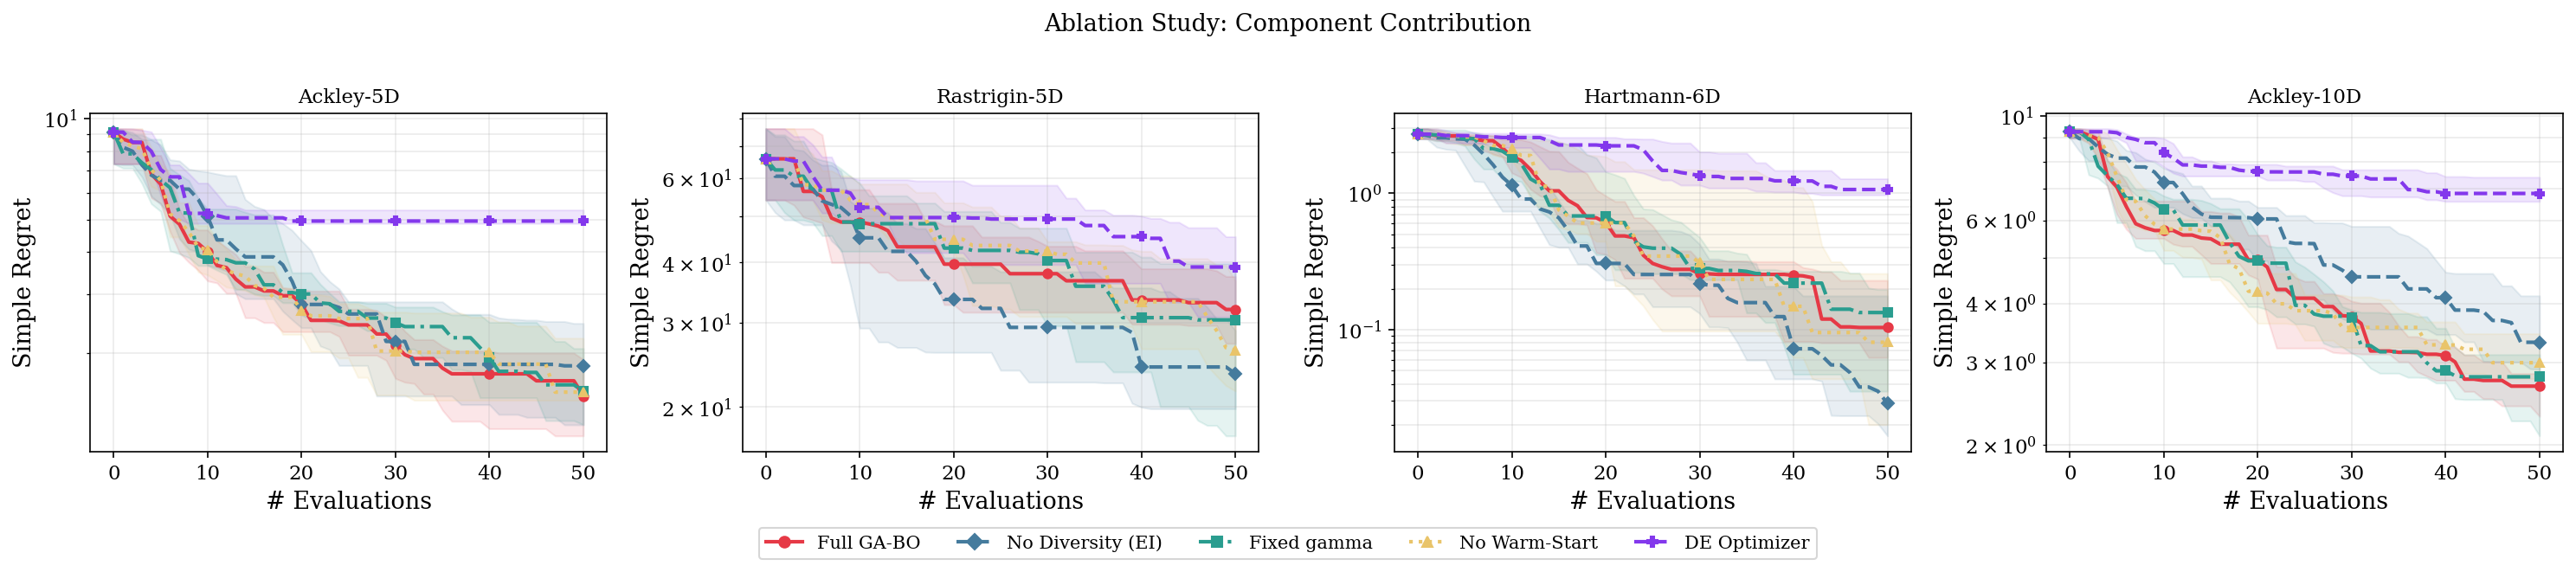

Saved figures/ablation_convergence.pdf


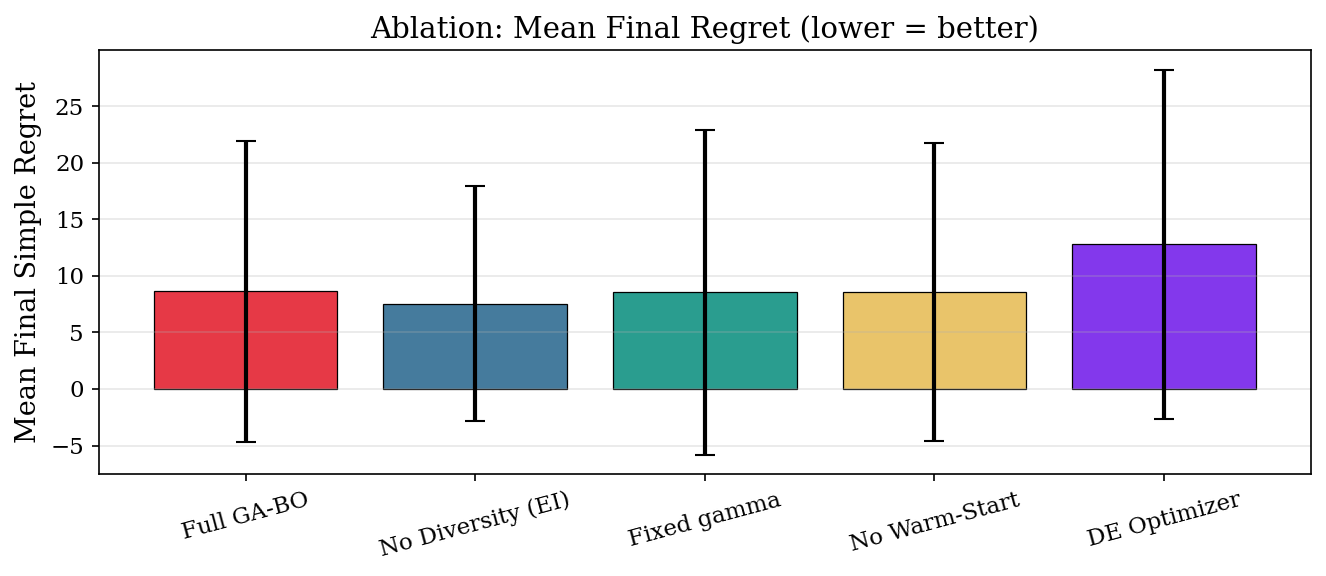

Saved figures/ablation_bar.pdf


In [23]:
# Ablation convergence plot
ABLATION_STYLES = {
    'Full GA-BO':        dict(color='#E63946', ls='-',  marker='o', label='Full GA-BO'),
    'No Diversity (EI)': dict(color='#457B9D', ls='--', marker='D', label='No Diversity (EI)'),
    'Fixed gamma':       dict(color='#2A9D8F', ls='-.', marker='s', label='Fixed gamma'),
    'No Warm-Start':     dict(color='#E9C46A', ls=':',  marker='^', label='No Warm-Start'),
    'DE Optimizer':      dict(color='#8338EC', ls='--', marker='P', label='DE Optimizer'),
}

fn_names = list(ABLATION_FUNCTIONS.keys())
fig, axes = plt.subplots(1, len(fn_names),
                          figsize=(5*len(fn_names), 4), squeeze=False)
axes = axes.flatten()

for ax_i, fname in enumerate(fn_names):
    ax    = axes[ax_i]
    f_opt = ABLATION_FUNCTIONS[fname].global_optimum
    for mname, st in ABLATION_STYLES.items():
        if mname not in ABL_RESULTS or fname not in ABL_RESULTS[mname]:
            continue
        runs = ABL_RESULTS[mname][fname]
        if not runs: continue
        curves = np.array([np.array(r.best_values) - f_opt for r in runs])
        med = np.median(curves, axis=0)
        q25 = np.percentile(curves, 25, axis=0)
        q75 = np.percentile(curves, 75, axis=0)
        xs  = np.arange(len(med))
        ax.semilogy(xs, np.maximum(med, 1e-10),
                    color=st['color'], ls=st['ls'],
                    marker=st['marker'], markevery=10,
                    markersize=5, label=st['label'])
        ax.fill_between(xs, np.maximum(q25, 1e-10),
                        np.maximum(q75, 1e-10),
                        alpha=0.12, color=st['color'])
    ax.set_title(fname, fontsize=11)
    ax.set_xlabel('# Evaluations')
    ax.set_ylabel('Simple Regret')
    ax.grid(True, which='both', alpha=0.25)

handles = [plt.Line2D([0],[0], color=st['color'], ls=st['ls'],
                       marker=st['marker'], markersize=6, label=st['label'])
           for mname, st in ABLATION_STYLES.items()]
fig.legend(handles=handles, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)
plt.suptitle('Ablation Study: Component Contribution', fontsize=13, y=1.01)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/ablation_convergence.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/ablation_convergence.pdf')

# Bar chart: mean final regret per variant
abl_means, abl_stds, abl_labels, abl_colors = [], [], [], []
for mname, st in ABLATION_STYLES.items():
    vals = []
    for fname in ABLATION_FUNCTIONS:
        f_opt = ABLATION_FUNCTIONS[fname].global_optimum
        if mname in ABL_RESULTS and fname in ABL_RESULTS[mname]:
            vals += [r.best_values[-1] - f_opt
                     for r in ABL_RESULTS[mname][fname]]
    if vals:
        abl_means.append(float(np.mean(vals)))
        abl_stds.append(float(np.std(vals)))
        abl_labels.append(mname)
        abl_colors.append(st['color'])

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.bar(abl_labels, abl_means, yerr=abl_stds, capsize=5,
        color=abl_colors, edgecolor='black', linewidth=0.6)
ax2.set_ylabel('Mean Final Simple Regret')
ax2.set_title('Ablation: Mean Final Regret (lower = better)')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ablation_bar.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/ablation_bar.pdf')


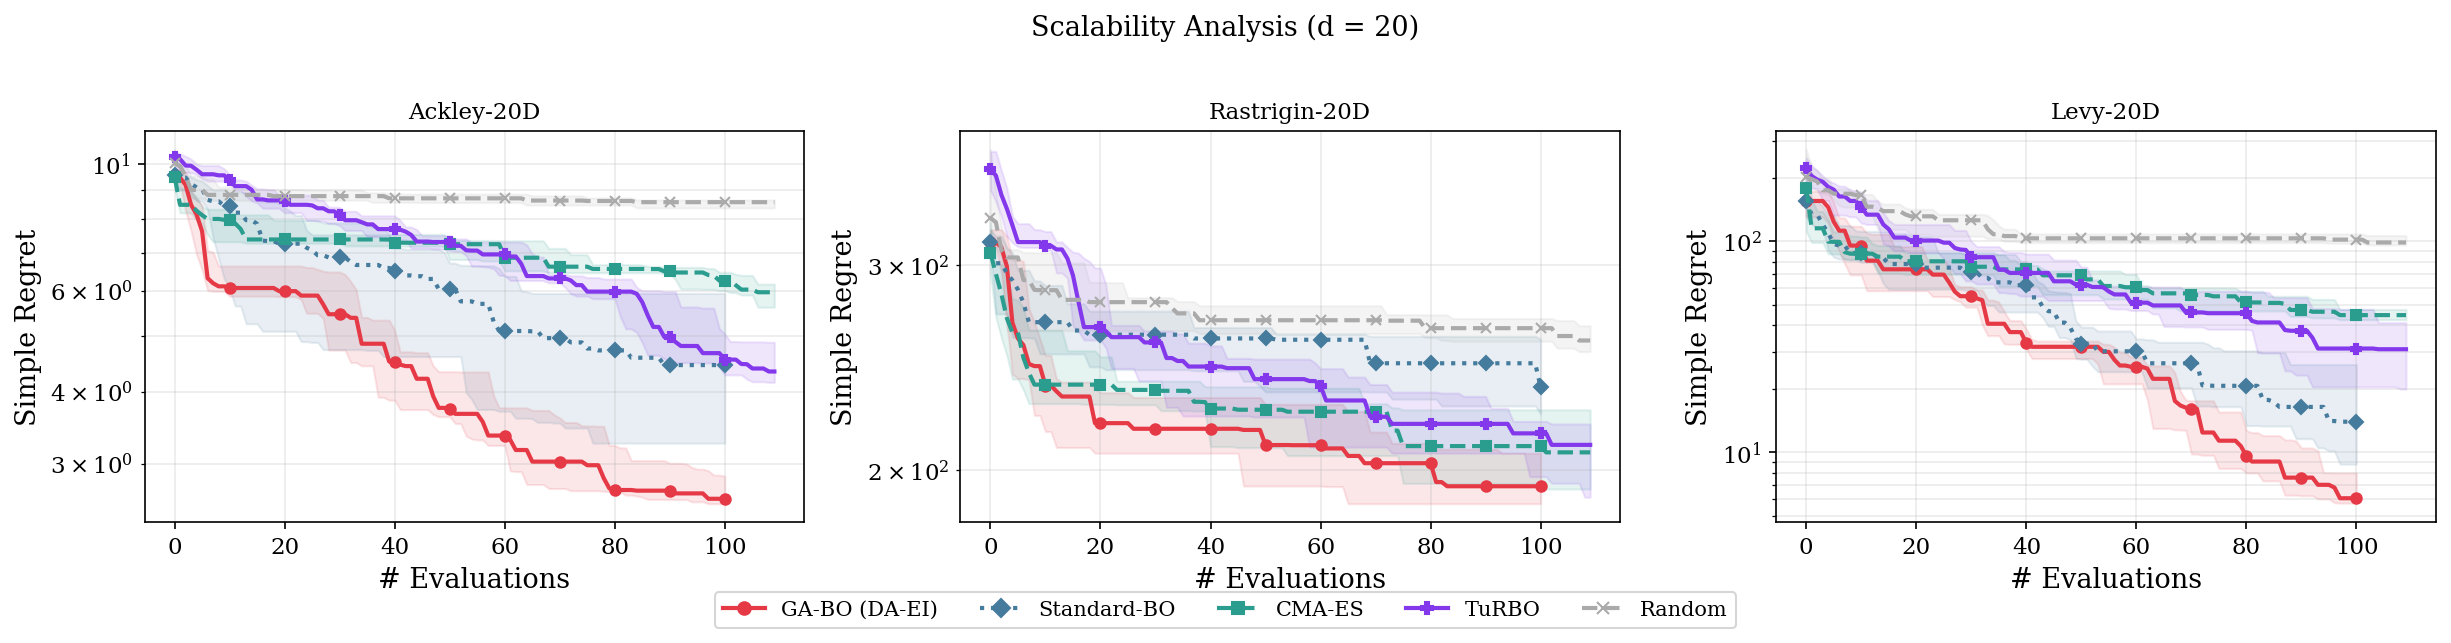

Saved figures/scalability_convergence.pdf

=== Scalability (d=20): Mean Simple Regret ===
Function       Ackley-20D  Levy-20D  Rastrigin-20D       Avg
Method                                                      
GA-BO (DA-EI)      2.6759    6.7141       194.1800   67.8567
TuRBO              4.6517   32.8936       202.8024   80.1159
CMA-ES             5.9115   46.3337       210.4731   87.5728
Standard-BO        4.6269   23.5875       237.1230   88.4458
Random             8.5129   99.4342       258.4035  122.1169
Saved results/scalability_summary.csv


In [24]:
# Scalability convergence plot
plot_results(SCALE_RESULTS, SCALABILITY_FUNCTIONS,
             'Scalability Analysis (d = 20)',
             'scalability_convergence.pdf', n_cols=3)

# Summary: final regret per method per 20D function
scale_rows = []
for mname in SCALABILITY_METHODS:
    for fname in SCALABILITY_FUNCTIONS:
        f_opt = SCALABILITY_FUNCTIONS[fname].global_optimum
        if mname in SCALE_RESULTS and fname in SCALE_RESULTS[mname]:
            runs = SCALE_RESULTS[mname][fname]
            regrets = [r.best_values[-1] - f_opt for r in runs]
            scale_rows.append({'Method': mname, 'Function': fname,
                               'Mean': np.mean(regrets),
                               'Std':  np.std(regrets)})
scale_df = pd.DataFrame(scale_rows)
if not scale_df.empty:
    pivot_sc = scale_df.pivot_table(index='Method', columns='Function',
                                     values='Mean')
    pivot_sc['Avg'] = pivot_sc.mean(axis=1)
    print('\n=== Scalability (d=20): Mean Simple Regret ===')
    print(pivot_sc.sort_values('Avg').round(4).to_string())
    scale_df.to_csv('results/scalability_summary.csv', index=False)
    print('Saved results/scalability_summary.csv')


In [25]:
# ── Summary table: ALL experiments combined ────────────────────────────────
def build_summary_table(all_exp: dict) -> pd.DataFrame:
    """
    all_exp = {'Engineering': (results, functions), 'OpenML': ...}
    Returns pivoted mean regret / accuracy table.
    """
    rows = []
    for exp_name, (results, functions) in all_exp.items():
        for mname, fd in results.items():
            for fname, run_list in fd.items():
                if not run_list: continue
                f_opt = functions[fname].global_optimum
                regrets = [r.best_values[-1] - f_opt for r in run_list]
                rows.append(dict(
                    Experiment=exp_name, Method=mname, Function=fname,
                    Mean=np.mean(regrets), Std=np.std(regrets),
                    Median=np.median(regrets)
                ))
    return pd.DataFrame(rows)


exp_dict = {'Engineering': (ENG_RESULTS, ENGINEERING_FUNCTIONS)}
exp_dict['Mixed-Variable'] = (MIX_RESULTS, {'MLP-Mixed': mlp_fn})
if OML_RESULTS:
    exp_dict['OpenML'] = (OML_RESULTS, OPENML_HPO_FUNCTIONS)
try:
    exp_dict['Ablation']    = (ABL_RESULTS,   ABLATION_FUNCTIONS)
    exp_dict['Scalability'] = (SCALE_RESULTS, SCALABILITY_FUNCTIONS)
except NameError:
    pass  # experiments not yet run

summary_df = build_summary_table(exp_dict)

# Pivot: methods as rows, functions as columns
pivot = summary_df.pivot_table(
    index='Method', columns='Function',
    values='Mean', aggfunc='mean'
)
pivot['Avg_Rank'] = pivot.rank(axis=0).mean(axis=1)
pivot_sorted = pivot.sort_values('Avg_Rank')

print('\n=== Summary: Mean Simple Regret (lower is better) ===')
print(pivot_sorted.round(4).to_string())
summary_df.to_csv('results/full_summary.csv', index=False)
print('\nFull summary saved → results/full_summary.csv')


=== Summary: Mean Simple Regret (lower is better) ===
Function           Ackley-10D  Ackley-20D  Ackley-5D  Hartmann-6D  Levy-20D  MLP-Mixed  PressureVessel  Rastrigin-20D  Rastrigin-5D  SpeedReducer  TensionSpring  WeldedBeam  Avg_Rank
Method                                                                                                                                                                                
Optuna-TPE                NaN         NaN        NaN          NaN       NaN     0.0190      11196.6163            NaN           NaN      881.6707      3036.0233      2.1084     2.200
Fixed gamma            2.7154         NaN     1.6213       0.1251       NaN        NaN             NaN            NaN       29.6854           NaN            NaN         NaN     2.250
Full GA-BO             2.5971         NaN     1.5351       0.1329       NaN        NaN             NaN            NaN       30.1905           NaN            NaN         NaN     2.250
TuRBO                     NaN 

In [26]:
# ── Win/Loss/Tie matrix vs all baselines ──────────────────────────────────
from scipy.stats import wilcoxon

def wlt_matrix(results, functions, proposed='GA-BO (DA-EI)'):
    baselines = [m for m in results if m != proposed]
    rows = []
    for base in baselines:
        w = l = t = sig = 0
        for fname in functions:
            f_opt  = functions[fname].global_optimum
            rp = [r.best_values[-1]-f_opt for r in results[proposed][fname]]
            rb = [r.best_values[-1]-f_opt for r in results[base][fname]]
            if not rp or not rb: continue
            n = min(len(rp), len(rb))
            diff = np.array(rp[:n]) - np.array(rb[:n])
            if   np.median(diff) < -1e-8: w += 1
            elif np.median(diff) >  1e-8: l += 1
            else: t += 1
            try:
                _, p = wilcoxon(rp[:n], rb[:n], alternative='less')
                if p < 0.05: sig += 1
            except Exception: pass
        rows.append({'vs': base, 'W': w, 'L': l, 'T': t, 'Sig(p<0.05)': sig})

    df = pd.DataFrame(rows).set_index('vs')
    print(f'\n=== GA-BO (DA-EI) Win/Loss/Tie vs Baselines ===')
    print(df.to_string())
    return df


wlt_eng = wlt_matrix(ENG_RESULTS, ENGINEERING_FUNCTIONS)
if OML_RESULTS:
    wlt_oml = wlt_matrix(OML_RESULTS, OPENML_HPO_FUNCTIONS)


=== GA-BO (DA-EI) Win/Loss/Tie vs Baselines ===
             W  L  T  Sig(p<0.05)
vs                               
Standard-BO  1  2  1            0
CMA-ES       1  3  0            1
Optuna-TPE   1  3  0            1
TuRBO        0  4  0            0
Random       2  2  0            2


---
## Section 9 — Recommended Public Datasets Summary

All datasets used in this paper are **freely available** with no registration required:

| Dataset | Source | License | URL |
|---------|--------|---------|-----|
| Welded Beam Design | Ragsdell & Phillips (1976) | Public domain | Classic paper |
| Pressure Vessel | Kannan & Kramer (1994) | Public domain | Classic paper |
| Tension Spring | Arora (1989) | Public domain | Classic paper |
| Speed Reducer | Golinski (1970) | Public domain | Classic paper |
| Breast Cancer Wisconsin | UCI / sklearn | BSD | `sklearn.datasets` |
| Diabetes | OpenML ID 37 | CC-BY | openml.org/d/37 |
| Sonar | OpenML ID 40 | CC-BY | openml.org/d/40 |
| BankNote Authentication | OpenML ID 1462 | CC-BY | openml.org/d/1462 |
| WDBC | OpenML ID 1510 | CC-BY | openml.org/d/1510 |

**Standard benchmarks also used:**
Branin, Ackley, Rastrigin, Rosenbrock, Hartmann-6D, Levy — all classical functions from optimization literature (no licensing restriction).


In [27]:
print('='*60)
print('PART 3 COMPLETE')
print('='*60)
print('Figures saved to: figures/')
print('Results saved to: results/')
print()
print('For paper writing:')
print('  - Section 4: Theory → Propositions 1-3 + Fig theory_acquisition.pdf')
print('  - Section 5: Engineering → Fig engineering_convergence.pdf')
print('  - Section 6: Mixed-variable → Fig mixed_var_convergence.pdf')
print('  - Section 7: OpenML → Fig openml_convergence.pdf')
print('  - All WLT tables → wlt_matrix output above')
print()
print('Target journals:')
print('  Q1: Applied Soft Computing / Expert Systems with Applications')
print('  Q1: Swarm and Evolutionary Computation')
print('  Q1: IEEE Transactions on Evolutionary Computation (with theory)')

PART 3 COMPLETE
Figures saved to: figures/
Results saved to: results/

For paper writing:
  - Section 4: Theory → Propositions 1-3 + Fig theory_acquisition.pdf
  - Section 5: Engineering → Fig engineering_convergence.pdf
  - Section 6: Mixed-variable → Fig mixed_var_convergence.pdf
  - Section 7: OpenML → Fig openml_convergence.pdf
  - All WLT tables → wlt_matrix output above

Target journals:
  Q1: Applied Soft Computing / Expert Systems with Applications
  Q1: Swarm and Evolutionary Computation
  Q1: IEEE Transactions on Evolutionary Computation (with theory)
